In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math

In [7]:
df = pd.read_json(Path("traffic.jsonl"), lines=True)
df

,road,depature,arrival
0,B->C->E,13:17,15:25
1,A->C->E,07:07,08:47
2,A->C->E,07:59,09:32
3,B->C->E,14:21,16:29
4,B->C->D,10:09,11:13
...,...,...,...
1026,A->C->D,15:44,17:32
1027,A->C->E,15:24,17:00
1028,B->C->E,10:23,12:26
1029,A->C->D,11:18,12:40


In [9]:
dep_min_min = int(df["dep_min"].min())
dep_min_max = int(df["dep_min"].max())
# Bins & Zentren bereiten
edges = list(range((dep_min_min // 15) * 15,
                    ((dep_min_max // 15) + 1) * 15 + 1,
                    15))
centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges) - 1)]

KeyError: 'dep_min'

KeyError: 'dep_min'

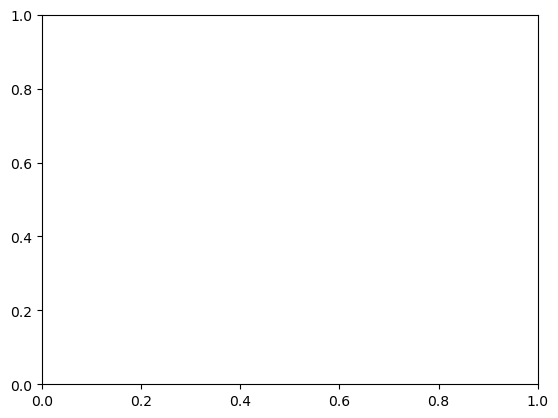

In [10]:
fig, ax = plt.subplots()

for route, sub in df.groupby("road", sort=True):
    # Punkte
    ax.scatter(sub["dep_min"], sub["duration_min"], alpha=0.35, label=f"{route} (pts)")
    # Binned mean
    bin_ids = pd.cut(sub["dep_min"], bins=edges, right=False, include_lowest=True, labels=False)
    binned = (
        pd.DataFrame({"bin": bin_ids, "duration": sub["duration_min"]})
         .dropna()
         .groupby("bin", as_index=False)["duration"].mean()
        )
    if not binned.empty:
        x_line = [centers[int(i)] for i in binned["bin"]]
        y_line = binned["duration"].to_list()
        ax.plot(x_line, y_line, linewidth=2, label=f"{route} (binned mean)")

 # Achsenbeschriftung / Ticks in HH:MM
ax.set_xlabel("Departure time (minutes since midnight)")
ax.set_ylabel("Trip duration (minutes)")
ax.set_title("Duration vs. departure time by route\n(with binned mean to reveal trends/periodicity)")

start_hour = dep_min_min // 60
end_hour = math.ceil(dep_min_max / 60)
xticks = [h * 60 for h in range(start_hour, end_hour + 1)]
ax.set_xticks(xticks)
ax.set_xticklabels([f"{h:02d}:00" for h in range(start_hour, end_hour + 1)])

ax.legend(loc="best", ncol=2, frameon=False)
plt.tight_layout()
plt.show()
